In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns
from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

In [5]:
df_CCI = pd.read_csv('../CCI.csv')
# df_CCI = df_CCI[['REF_AREA', 'UNIT_MEASURE', 'TIME_PERIOD', 'OBS_VALUE']]
# df_CCI["YEAR"] = df_CCI["TIME_PERIOD"].str[:4].astype(int)
# df_CCI["MONTH"] = df_CCI["TIME_PERIOD"].str[5:7].astype(int)
# df_can = df_CCI[df_CCI["REF_AREA"] == "US"].copy()
# df_can["REF_AREA"] = "CAN"
# df_CCI = pd.concat([df_CCI, df_can], ignore_index=True)
# df_CCI["REF_AREA"] = df_CCI["REF_AREA"].replace({
#     "AUS": "AU",
#     "CAN": "CA",
#     "GBR": "GB",
#     "NZL": "NZ",
#     "USA": "US"})
# df_CCI = df_CCI[df_CCI["YEAR"] >= 2008]
# df_CCI.sort_values(["REF_AREA", "TIME_PERIOD"], inplace=True)
# df_CCI.reset_index(drop=True, inplace=True)
# df_CCI.to_csv('CCI_.csv', index=False)

In [6]:
df = pd.read_csv('../dataset.csv')
df_train = pd.read_csv('../features/train.csv')

# df["launched_at-year"] = pd.to_datetime(df["launched_at"]).dt.year
# df["launched_at-month"] = pd.to_datetime(df["launched_at"]).dt.month
# df = df.rename(columns={"usd_pledged": "pledged_usd"})
# df_merge = pd.merge(
#     df, 
#     df_CCI[['REF_AREA', 'YEAR', 'MONTH', 'OBS_VALUE']], 
#     left_on=['country', 'launched_at-year', 'launched_at-month'], 
#     right_on=['REF_AREA', 'YEAR', 'MONTH'], 
#     how='left'
# )
# df_merge = df_merge.rename(columns={'OBS_VALUE': 'CCI_index'})
# df_merge = df_merge.drop(columns=['REF_AREA', 'YEAR', 'MONTH'])
# df_merge.to_csv('dataset_update.csv', index=False)

In [4]:
df.head(3)

,id,name,blurb,state,launched_at,deadline,duration,country,category.parent_name,category.name,goal_usd,pledged_usd,backers_count,launched_at-year,launched_at-month,CCI_index
0,1432554512,Help get Das Good seasonings and sauces to sup...,Das Good Inc goal is to make cooking easy and ...,failed,2018-12-05 23:26:21,2019-02-03 23:26:21,60,US,Food,Restaurants,75000.0,266.0,6,2018,12,101.2287
1,1925377347,"""The Applicant: Interviews Are Hell""",A web series about the soul crushing exercise ...,failed,2016-12-26 13:45:21,2017-01-25 13:45:21,30,US,Film & Video,Webseries,6000.0,260.0,2,2016,12,101.2478
2,1876427386,5 Reasons to Hate Christmas,A romantic comedy mini series following a self...,failed,2018-04-10 18:33:16,2018-05-10 18:33:16,30,US,Film & Video,Webseries,10000.0,35.0,2,2018,4,101.5817


In [5]:
print(f"Rows in df: {len(df)}\n")
print(f"Rows in df_train: {len(df_train)}\n")

Rows in df: 110161

Rows in df_train: 66096



In [6]:
print(f"Columns in df: {df.columns}\n")
print(f"Columns in df_train: {df_train.columns}")

Columns in df: Index(['id', 'name', 'blurb', 'state', 'launched_at', 'deadline', 'duration',
       'country', 'category.parent_name', 'category.name', 'goal_usd',
       'pledged_usd', 'backers_count', 'launched_at-year', 'launched_at-month',
       'CCI_index'],
      dtype='object')

Columns in df_train: Index(['id', 'name', 'blurb', 'state', 'launched_at', 'deadline', 'duration',
       'category.name', 'goal_usd', 'pledged_usd', 'backers_count',
       'launched_at-year', 'launched_at-month', 'CCI_index', 'target',
       'cat_Art', 'cat_Comics', 'cat_Crafts', 'cat_Dance', 'cat_Design',
       'cat_Fashion', 'cat_Film & Video', 'cat_Food', 'cat_Games',
       'cat_Journalism', 'cat_Music', 'cat_Photography', 'cat_Publishing',
       'cat_Technology', 'cat_Theater', 'country_AU', 'country_CA',
       'country_GB', 'country_NZ', 'country_US', 'blurb_length',
       'sentiment_score', 'readability_score', 'name_blurb_similarity',
       'log_goal', 'CCI_per_goal', 'z-score_log_goal']

# Original Data Visualization

## State

<Axes: ylabel='count'>

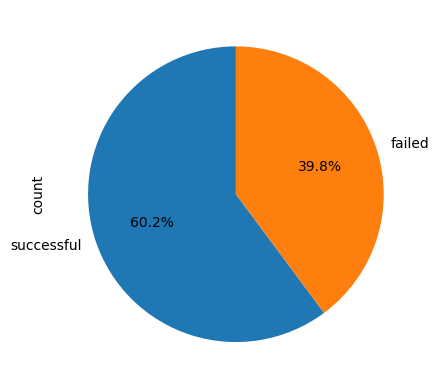

In [7]:
df["state"].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)

## Project year

<Axes: >

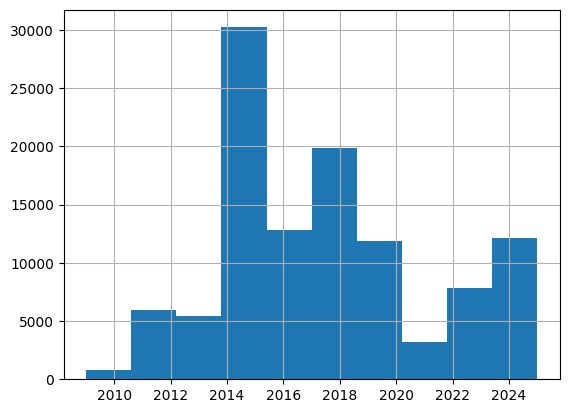

In [8]:
df["launched_at-year"].hist()

## Country

<Axes: >

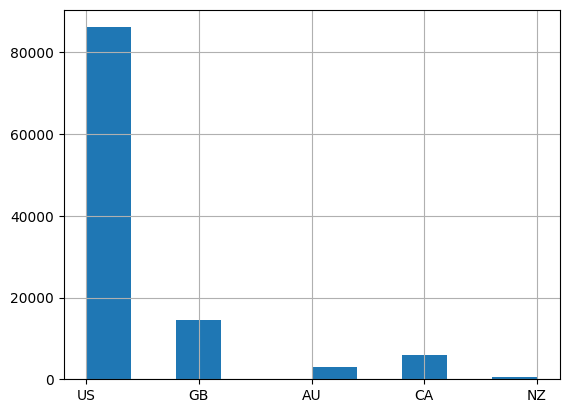

In [9]:
df["country"].hist()

## Duration

<Axes: >

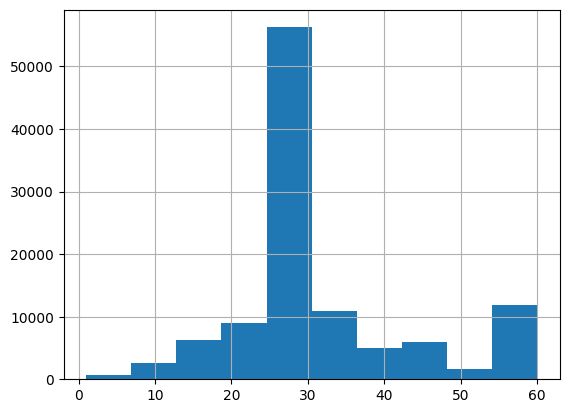

In [19]:
df["duration"].hist()

## Project category

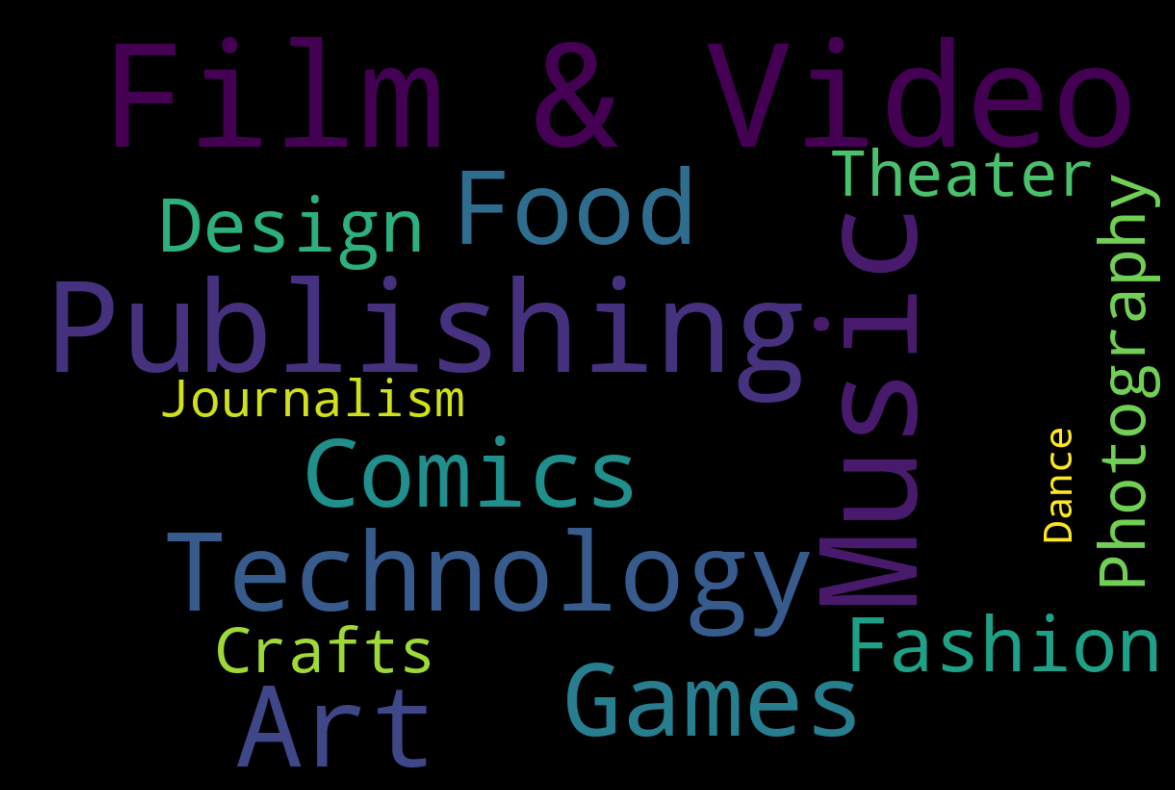

In [ ]:
counts_dict = df['category.parent_name'].value_counts().to_dict()

categories_sorted = sorted(counts_dict.keys(), key=lambda x: counts_dict[x], reverse=True)
num_categories = len(categories_sorted)
cmap = plt.get_cmap('viridis')
color_map = {cat: cmap(i / (num_categories - 1)) for i, cat in enumerate(categories_sorted)}

def viridis_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    rgba_color = color_map.get(word, (1, 1, 1, 1))
    return tuple(int(c * 255) for c in rgba_color[:3])

wc = WordCloud(
    background_color='black',
    color_func=viridis_color_func,
    width=1200, height=800,
    max_font_size=150,
    min_font_size=20,
    random_state=42,
    prefer_horizontal=0.7,
    collocations=False
)

wc.generate_from_frequencies(counts_dict)

fig, ax = plt.subplots(figsize=(15, 8), facecolor='black')
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

plt.tight_layout()
plt.show()

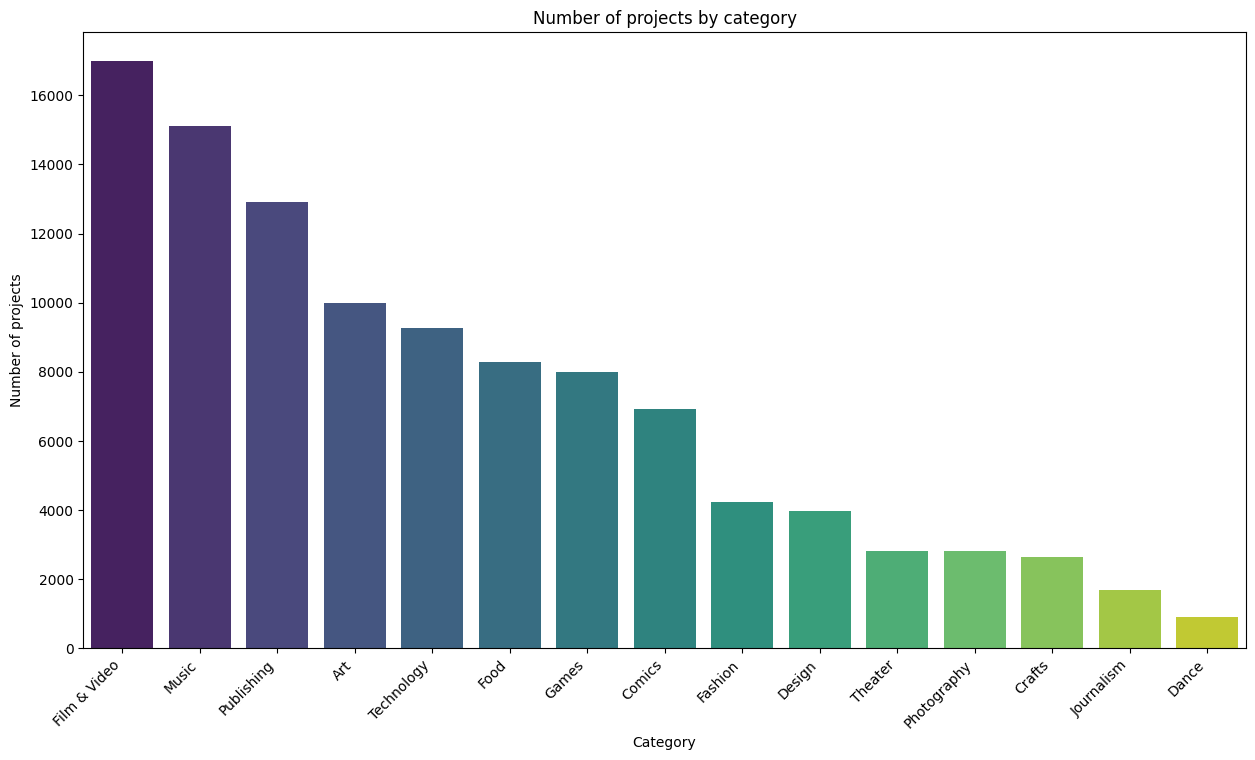

In [26]:
# # Separated bins
# plt.figure(figsize=(20, 10))
# df["category.parent_name"].hist(bins=30)
# plt.show()

plt.figure(figsize=(15, 8))
sns.countplot(data=df, x="category.parent_name", 
              order=df["category.parent_name"].value_counts().index,
              palette="viridis")

plt.xticks(rotation=45, ha='right')
plt.title("Number of projects by category")
plt.xlabel("Category")
plt.ylabel("Number of projects")
plt.show()

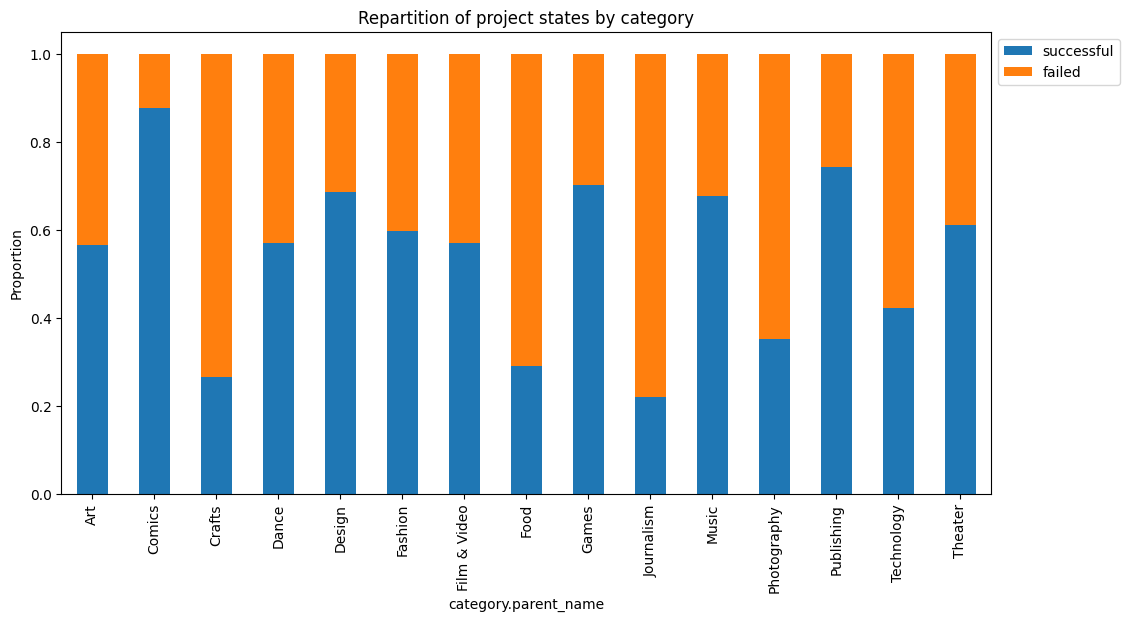

In [29]:
repartition_pct = pd.crosstab(df['category.parent_name'], df['state'], normalize='index')

repartition_pct.iloc[:, ::-1].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Repartition of project states by category")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.ylabel("Proportion")
plt.show()

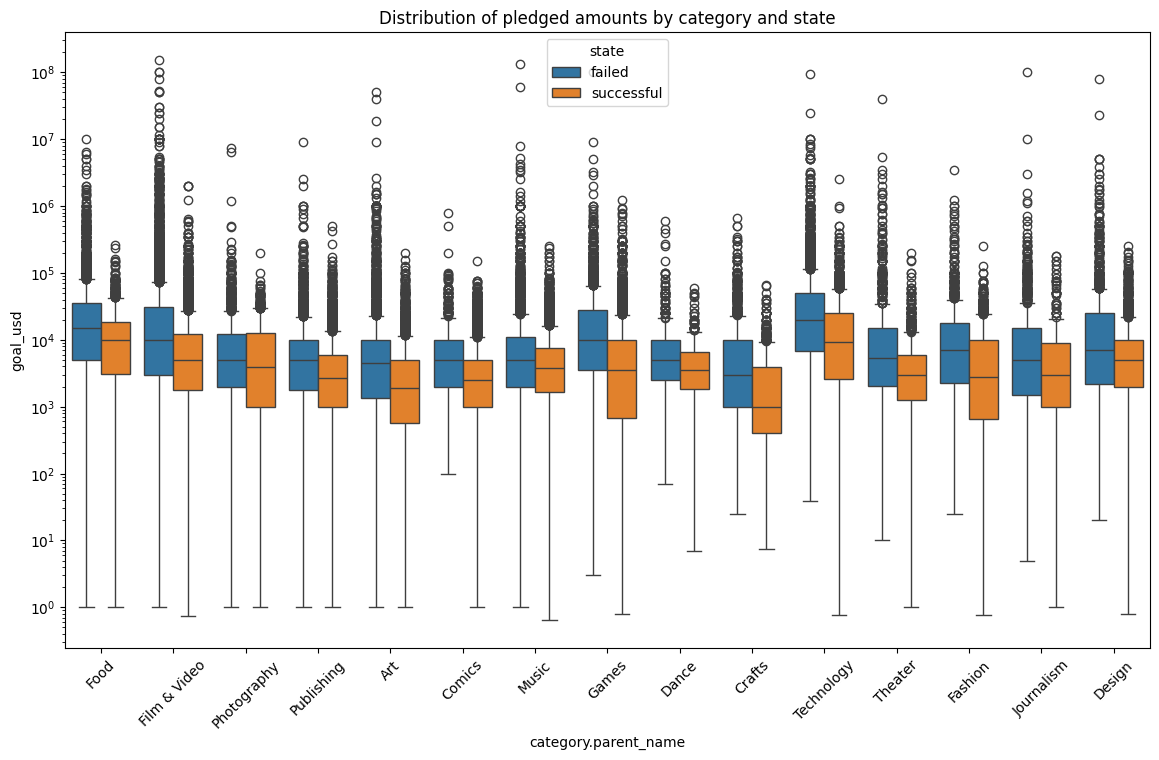

In [30]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='category.parent_name', y='goal_usd', hue='state')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Distribution of pledged amounts by category and state")
plt.show()

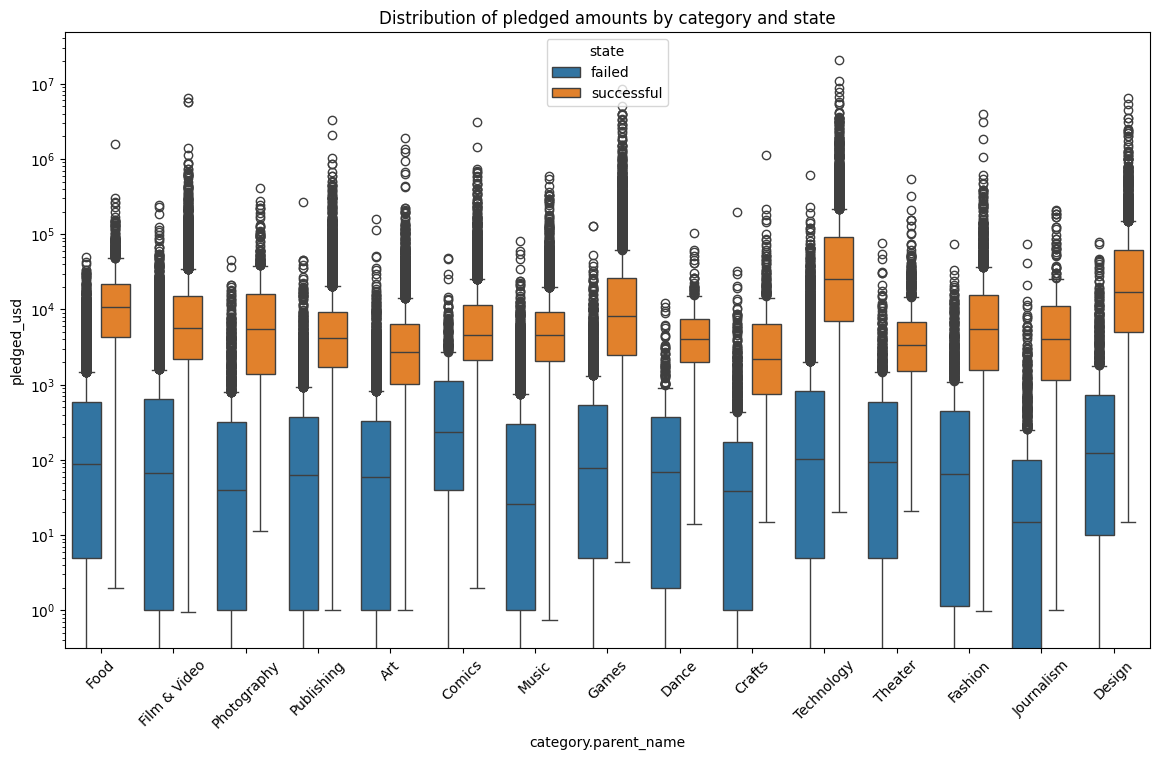

In [31]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='category.parent_name', y='pledged_usd', hue='state')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title("Distribution of pledged amounts by category and state")
plt.show()

## Number of backers

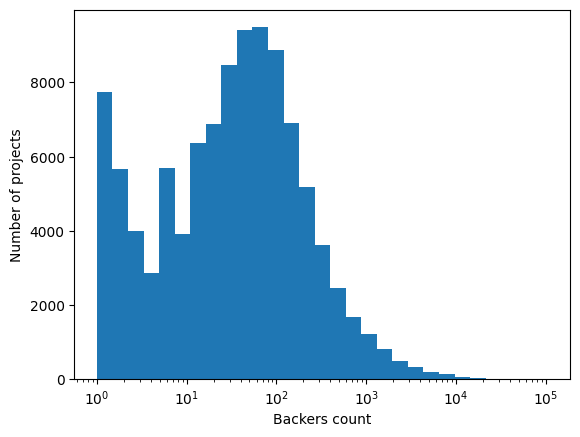

In [35]:
bins = np.logspace(np.log10(df["backers_count"].min() + 1), 
                   np.log10(df["backers_count"].max()), 
                   30)

plt.hist(df["backers_count"], bins=bins)
plt.xscale('log')

plt.xlabel("Backers count")
plt.ylabel("Number of projects")
plt.show()

## Goal & Pledged

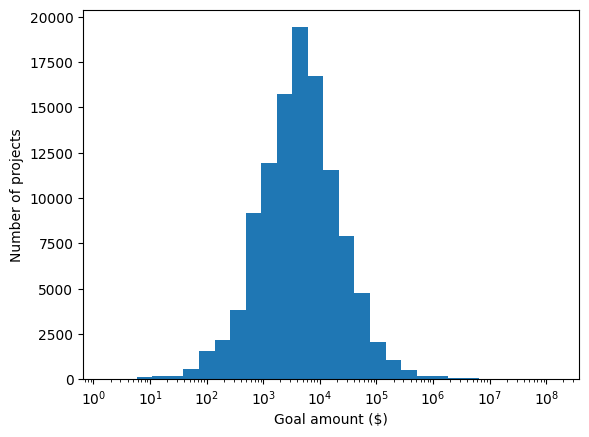

In [36]:
bins = np.logspace(np.log10(df["goal_usd"].min() + 1), 
                   np.log10(df["goal_usd"].max()), 
                   30)

plt.hist(df["goal_usd"], bins=bins)
plt.xscale('log')

plt.xlabel("Goal amount ($)")
plt.ylabel("Number of projects")
plt.show()

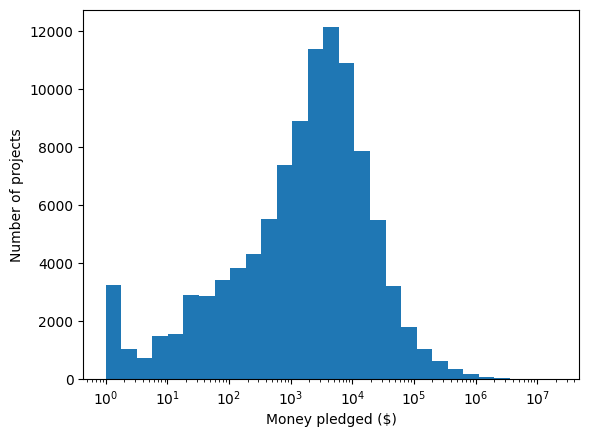

In [37]:
bins = np.logspace(np.log10(df["pledged_usd"].min() + 1), 
                   np.log10(df["pledged_usd"].max()), 
                   30)

plt.hist(df["pledged_usd"], bins=bins)
plt.xscale('log')

plt.xlabel("Money pledged ($)")
plt.ylabel("Number of projects")
plt.show()

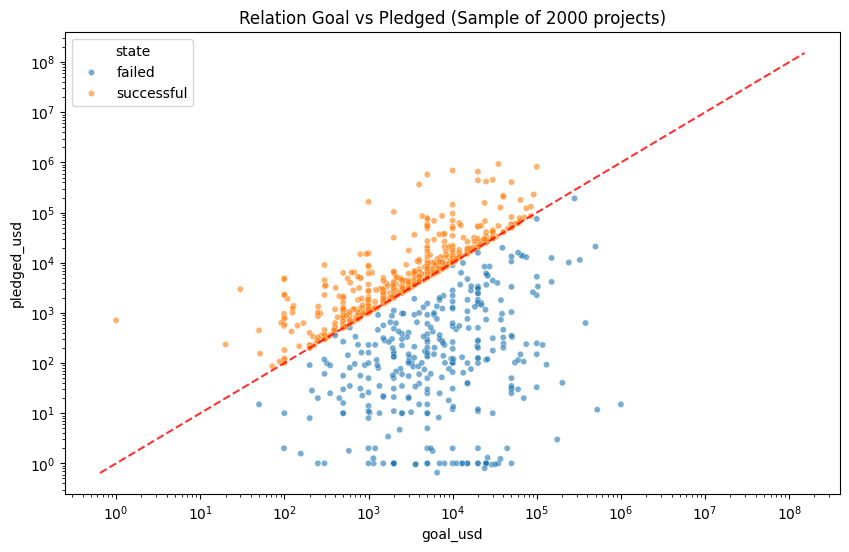

In [40]:
# plt.figure(figsize=(10, 6))

# sns.scatterplot(data=df, x="goal_usd", y="pledged_usd", alpha=0.5, hue="state")

# plt.xscale('log')
# plt.yscale('log')
# limits = [min(df["goal_usd"].min(), df["pledged_usd"].min()), 
#           max(df["goal_usd"].max(), df["pledged_usd"].max())]
# plt.plot(limits, limits, color='red', linestyle='--', label="Success threshold")

# plt.title("Relation between goal and pledged amounts")
# plt.legend()
# plt.show()



df_sample = df.sample(n=1000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sample, x="goal_usd", y="pledged_usd", alpha=0.6, hue="state", s=20)

plt.xscale('log')
plt.yscale('log')

# Ligne de succès
limits = [df["goal_usd"].min(), df["goal_usd"].max()]
plt.plot(limits, limits, color='red', linestyle='--', alpha=0.8)

plt.title("Relation Goal vs Pledged (Sample of 2000 projects)")
plt.show()

## Number of words in blurb

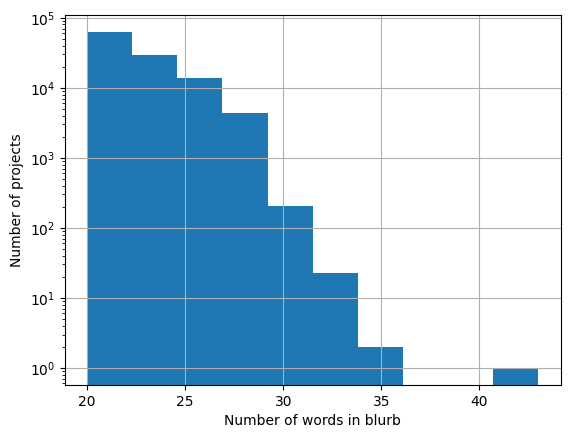

In [ ]:
df["words_number"] = df["blurb"].apply(lambda x: len(str(x).split()))
df["words_number"].hist(log=True)
plt.xlabel("Number of words in blurb")
plt.ylabel("Number of projects")
plt.show()

## Consumer Confidence Index (CCI)

In [47]:
areas = df_CCI["REF_AREA"].unique()
fig = px.line()
for area in areas:
    area_data = df_CCI[df_CCI["REF_AREA"] == area]
    fig.add_scatter(x=area_data["TIME_PERIOD"], y=area_data["OBS_VALUE"], mode="lines", name=area)
fig.update_xaxes(title_text="Year")
fig.update_yaxes(title_text="CCI")
fig.update_layout(title="Consumer Confidence Index by Area")

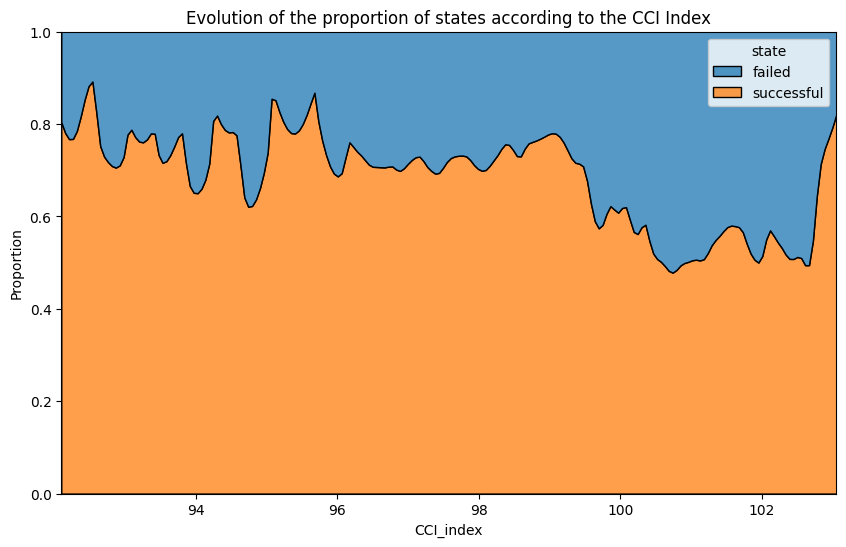

In [48]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="CCI_index", hue="state", multiple="fill", bw_adjust=0.5)

plt.title("Evolution of the proportion of states according to the CCI Index")
plt.ylabel("Proportion")
plt.show()

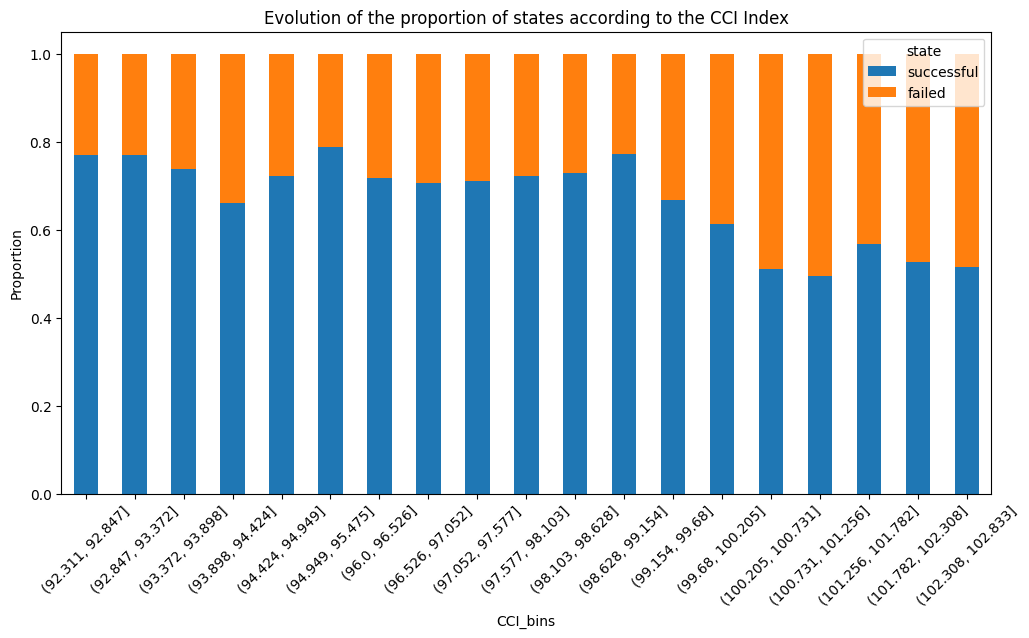

In [53]:
df['CCI_bins'] = pd.cut(df['CCI_index'], bins=20)

cci_repartition = pd.crosstab(df['CCI_bins'], df['state'], normalize='index')

cci_repartition.iloc[:, ::-1].plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title("Evolution of the proportion of states according to the CCI Index")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='CCI_index'>

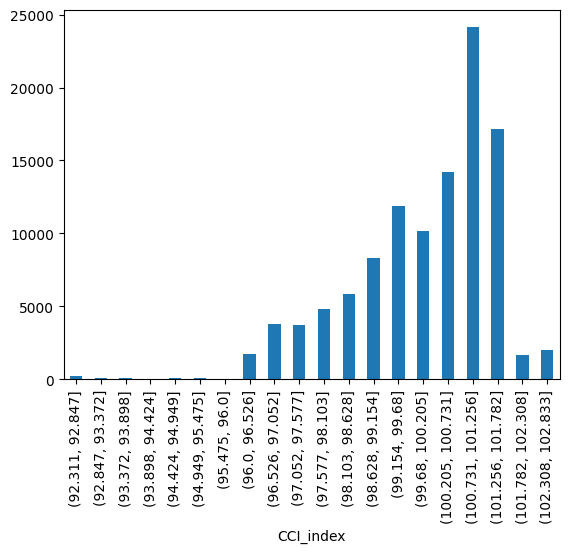

In [59]:
df.groupby(pd.cut(df['CCI_index'], bins=20)).size().plot(kind='bar')